### Exercise 1 - Separable Data: The Case The Perceptron Was Designed For

A - Generate the Data

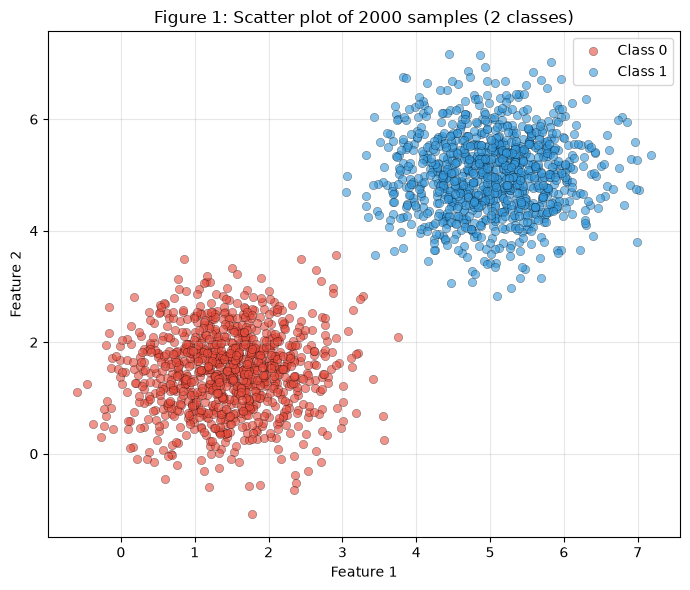

In [19]:
import numpy as np
import matplotlib.pyplot as plt

params = {
    0: {
        "mean": np.array([1.5, 1.5]), 
        "cov": np.array([
            [0.5, 0.0],
            [0.0, 0.5]
        ])
    },
    1: {
        "mean": np.array([5.0, 5.0]), 
        "cov": np.array([
            [0.5, 0.0],
            [0.0, 0.5]
        ])
    }
}

n_per_class = 1000
rng = np.random.default_rng(seed=42)

class_0 = rng.multivariate_normal(
    mean=params[0]["mean"],
    cov=params[0]["cov"],
    size=n_per_class,
)

class_1 = rng.multivariate_normal(
    mean=params[1]["mean"],
    cov=params[1]["cov"],
    size=n_per_class,
)

colors = ["#e74c3c", "#3498db"]
plt.figure(figsize=(7, 6))

plt.scatter(class_0[:, 0], class_0[:, 1], c=colors[0], label="Class 0", alpha=0.6, edgecolors="k", linewidths=0.3)
plt.scatter(class_1[:, 0], class_1[:, 1], c=colors[1], label="Class 1", alpha=0.6, edgecolors="k", linewidths=0.3)

plt.title("Figure 1: Scatter plot of 2000 samples (2 classes)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("./figures/figure1.png", dpi=150)
plt.show()

B - Implement the Perceptron

In [20]:
class Perceptron:
    def __init__(self, n_features, eta=0.01, rng=None):
        if rng is None:
            rng = np.random.default_rng()
        self.w = rng.normal(0, 0.01, size=n_features)
        self.b = 0.0
        self.eta = eta

    def step(self, z):
        return np.where(z >= 0, 1, 0)

    def predict(self, X):
        z = X @ self.w + self.b
        return self.step(z)

    def fit(self, X, y, max_epochs=100):
        accuracy_history = []

        for epoch in range(max_epochs):
            updated = False

            for xi, yi in zip(X, y):
                y_hat = self.step(xi @ self.w + self.b)
                error = yi - y_hat

                if error != 0:
                    self.w += self.eta * error * xi
                    self.b += self.eta * error
                    updated = True

            # accuracy on the full dataset after this epoch
            y_pred = self.predict(X)
            acc = np.mean(y_pred == y)
            accuracy_history.append(acc)

            if not updated:
                break

        return accuracy_history

C - Train and Mesure

In [21]:
import pandas as pd

X = np.vstack([class_0, class_1])
y = np.concatenate([np.zeros(n_per_class), np.ones(n_per_class)])

rng_train = np.random.default_rng(seed=42)
model = Perceptron(n_features=2, eta=0.01, rng=rng_train)
acc_history = model.fit(X, y, max_epochs=100)

accuracy_df = pd.DataFrame({
    "Epoch": range(1, len(acc_history) + 1),
    "Accuracy": acc_history
})
print(accuracy_df)

print(f"Epochs until convergence: {len(acc_history)}")
print(f"Final accuracy: {acc_history[-1]:.4f}")
print(f"Final w: {model.w}")
print(f"Final b: {model.b:.4f}")

    Epoch  Accuracy
0       1    0.5000
1       2    0.5025
2       3    0.5170
3       4    0.5170
4       5    0.5410
5       6    0.5310
6       7    0.5895
7       8    0.5840
8       9    0.8485
9      10    0.6030
10     11    0.8520
11     12    0.6530
12     13    0.6520
13     14    0.6860
14     15    0.6850
15     16    0.7260
16     17    0.8345
17     18    0.9405
18     19    0.7765
19     20    0.8835
20     21    0.9635
21     22    0.8070
22     23    0.9055
23     24    0.9700
24     25    0.8650
25     26    0.9485
26     27    1.0000
27     28    1.0000
Epochs until convergence: 28
Final accuracy: 1.0000
Final w: [0.05304435 0.02461711]
Final b: -0.2600


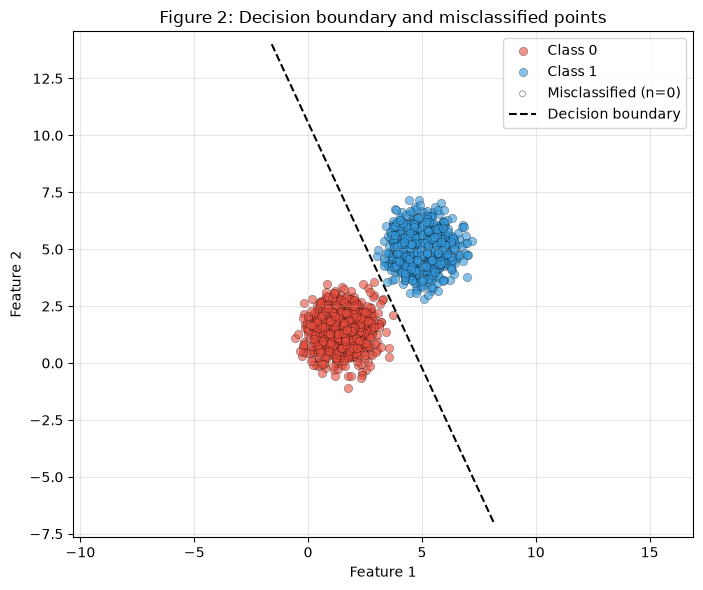

In [25]:
y_pred = model.predict(X)
misclassified = y_pred != y

plt.figure(figsize=(7, 6))

# correctly classified points, split by class for coloring
plt.scatter(X[(y == 0) & ~misclassified, 0], X[(y == 0) & ~misclassified, 1],
            c=colors[0], label="Class 0", alpha=0.6, edgecolors="k", linewidths=0.3)
plt.scatter(X[(y == 1) & ~misclassified, 0], X[(y == 1) & ~misclassified, 1],
            c=colors[1], label="Class 1", alpha=0.6, edgecolors="k", linewidths=0.3)

# misclassified points, marked with an X regardless of class
plt.scatter(X[misclassified, 0], X[misclassified, 1],
               facecolors="none", edgecolors="black", marker="o", s=18,
               linewidths=0.5, alpha=0.5, label=f"Misclassified (n={misclassified.sum()})")

# decision boundary: w1*x1 + w2*x2 + b = 0  ->  x2 = -(w1*x1 + b) / w2
x1_range = np.array([X[:, 0].min() - 1, X[:, 0].max() + 1])
w1, w2 = model.w
if w2 != 0:
    x2_range = -(w1 * x1_range + model.b) / w2
    plt.plot(x1_range, x2_range, "k--", linewidth=1.5, label="Decision boundary")
else:
    # vertical boundary if w2 == 0
    x_vert = -model.b / w1
    plt.axvline(x_vert, color="k", linestyle="--", linewidth=1.5, label="Decision boundary")

plt.title("Figure 2: Decision boundary and misclassified points")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.axis("equal")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("./figures/figure2.png", dpi=150)
plt.show()

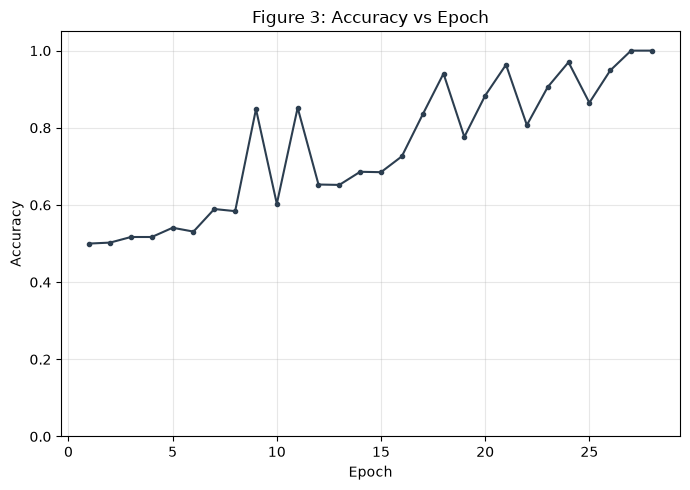

In [23]:
plt.figure(figsize=(7, 5))
plt.plot(accuracy_df["Epoch"], accuracy_df["Accuracy"], marker="o", markersize=3, color="#2c3e50")
plt.title("Figure 3: Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("./figures/figure3.png", dpi=150)
plt.show()